In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import nasdaqdatalink
from pandas_datareader import data as pdr
import statsmodels.api as sm
import numpy as np
import matplotlib.gridspec as gridspec
import quandl

In [153]:
nasdaqdatalink.ApiConfig.api_key = '99K8wcGMDBPgUdBXGNwT'

## 1. Pick assets and calculate monthly returns

In [154]:
tickers = [
    'SPY', # US equity
    'EEM', # EM equity
    'AGG', # US bond
    'EMB', # EM bond
    'HYG', # US high yield
    'GLD', # Gold
    'VNQ', # US Real estate
    'DBC', # Commodities
    'TIP', # US TIPS
    'BIL', # Cash / Short-term bonds
]

data = nasdaqdatalink.get_table('QUOTEMEDIA/PRICES', qopts={ 'columns': ['date', 'ticker', 'adj_close'] }, date={'gte': '2010-01-01', 'lte': '2024-01-02'}, ticker=tickers, paginate=True)
data = data.pivot(index='date', columns='ticker', values='adj_close').sort_index()
monthly_returns = data.resample('MS').first().pct_change().dropna()
monthly_returns.head()

ticker,AGG,BIL,DBC,EEM,EMB,GLD,HYG,SPY,TIP,VNQ
date,,,,,,,,,,
2010-02-01,0.011586,0.000218,-0.079239,-0.079607,-0.006563,-0.013206,-0.021315,-0.037678,0.012268,-0.033895
2010-03-01,0.004828,-0.000436,0.006454,0.007886,0.013783,0.009968,0.014612,0.025949,-0.012505,0.045771
2010-04-01,-0.001907,0.000436,0.025224,0.090863,0.025757,0.007585,0.018108,0.057177,-0.000366,0.098141
2010-05-01,0.008200,-0.000218,0.024187,-0.021749,0.006080,0.049610,0.021604,0.021647,0.023524,0.101508
2010-06-01,0.014405,0.000218,-0.122557,-0.115303,-0.017506,0.036119,-0.051124,-0.106523,0.001811,-0.102887


## 2. Normalize the results

In [155]:
z_score_returns = (monthly_returns - monthly_returns.mean()) / monthly_returns.std()

## 3. Macro data series
- **_(U.S. Federal Funds Effective Rate)_**
    - **Why it matters**: This is the primary policy rate affecting all interest-rate sensitive assets
        - Fixed Income: Changes in Fed policy rates drive bond yields.
        - Equities: Higher rates dampen equity valuations (future cashflows are discounted at a higher rate).
        - Commodities: Higher rates increase the financing costs for commodity producers.
- **_(U.S. Consumer Price Index (CPI) – MoM % Change)_**
    - **Why it matters**: Inflation pressures feed directly into interest rate expectations and real returns
        - Fixed Income: Higher inflation erodes real yields. Assets like TIP adjust to realized inflation.
        - Commodities: Seen as inflation hedges. Typically rise during high inflation times.
- **_(U.S. Industrial Production Index - MoM % Change)_**
    - **Why it matters**: A proxy for economic activity and growth.
        - Equities: Rising industrial output signals stronger corporate earnings.
        - Credit Spreads: Economic strength reduces default risk, tightening spreads in high-yield corporates.

In [156]:
series = [
    'FEDFUNDS', # U.S. Federal Funds Effective Rate
    'CPIAUCSL', # U.S. Consumer Price Index (CPI) – YoY % Change
    'INDPRO',   # U.S. Industrial Production Index
]

macro_data = pdr.get_data_fred(series, start='2010-01-01', end='2024-01-01')
macro_data['CPIAUCSL'] = macro_data['CPIAUCSL'].pct_change()
macro_data['INDPRO'] = macro_data['INDPRO'].pct_change()
macro_data['FEDFUNDS'] = macro_data['FEDFUNDS'] / 100
macro_data = macro_data.dropna()
macro_data.head()


,FEDFUNDS,CPIAUCSL,INDPRO
DATE,,,
2010-02-01,0.0013,-0.000952,0.003531
2010-03-01,0.0016,0.000331,0.007050
2010-04-01,0.0020,0.000230,0.003607
2010-05-01,0.0020,-0.000520,0.013715
2010-06-01,0.0018,-0.000419,0.002202


## 4. Regression of asset returns on macro factors

To determine if the macro data are relevant for asset returns, we can perform a multiple linear regression and analyze the results. Specifically, we:
- Look at betas and see if they're economically meaningful. i.e, are the coefficients _large_ enough? Do they meaningfully affect returns?
- Look at hypothesis tests for significance.

Since we're regressing on multiple exogenous variables, we look at the F-statistic to see if the coefficients are _jointly_ significant.

In [157]:
X = sm.add_constant(macro_data)
y = monthly_returns

summary = pd.DataFrame()
for ticker in tickers:
    y = monthly_returns[ticker]
    reg = sm.OLS(y, X).fit()
    summary[ticker] = pd.concat([
        reg.params,
        pd.Series([reg.fvalue], index=['f_stat']),
        pd.Series([reg.rsquared], index=['r_squared']),
    ])

summary


,SPY,EEM,AGG,EMB,HYG,GLD,VNQ,DBC,TIP,BIL
const,0.006360,-0.004624,0.003976,0.002838,0.001829,0.000214,0.009551,-0.018720,0.003587,-0.000009
FEDFUNDS,0.082836,0.041497,0.036797,0.153105,0.068992,0.172219,-0.041192,-0.271790,-0.035613,0.062838
CPIAUCSL,1.509452,3.025718,-1.198804,-0.828169,0.506153,1.114935,-0.739647,10.340973,-0.508510,-0.020396
INDPRO,1.045961,0.796358,0.093818,0.919703,0.636495,0.043282,1.474399,0.630963,0.098702,-0.007396
f_stat,7.694548,4.561561,3.262679,10.597963,9.235343,0.474764,7.337793,33.896627,0.723577,76.063444
r_squared,0.123387,0.077017,0.056322,0.162384,0.144524,0.008610,0.118343,0.382739,0.013063,0.581836


## Should the sample period be different?

I think the sample period (2010-2024) is sufficiently representative. As seen in the plot below, the period includes multiple macro regimes. We see periods of low/high interest rates, shocks to production (Covid), and both high and low inflation.

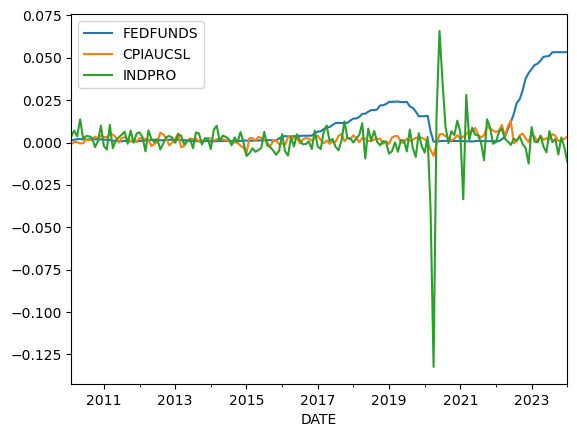

In [158]:
_ = macro_data.plot()

## 6. Out of sample analysis

In [159]:
oos_macro_data = pdr.get_data_fred(series, start='2024-01-01').dropna()
oos_macro_data['CPIAUCSL'] = oos_macro_data['CPIAUCSL'].pct_change()
oos_macro_data['INDPRO'] = oos_macro_data['INDPRO'].pct_change()
oos_macro_data['FEDFUNDS'] = oos_macro_data['FEDFUNDS'] / 100
oos_macro_data = oos_macro_data.dropna()

oos_data = nasdaqdatalink.get_table('QUOTEMEDIA/PRICES', qopts={ 'columns': ['date', 'ticker', 'adj_close'] }, date={'gte': '2024-01-01', 'lte': '2025-12-31'}, ticker=tickers, paginate=True)
oos_data = oos_data.pivot(index='date', columns='ticker', values='adj_close').sort_index()
oos_returns = oos_data.resample('MS').first().pct_change().dropna()

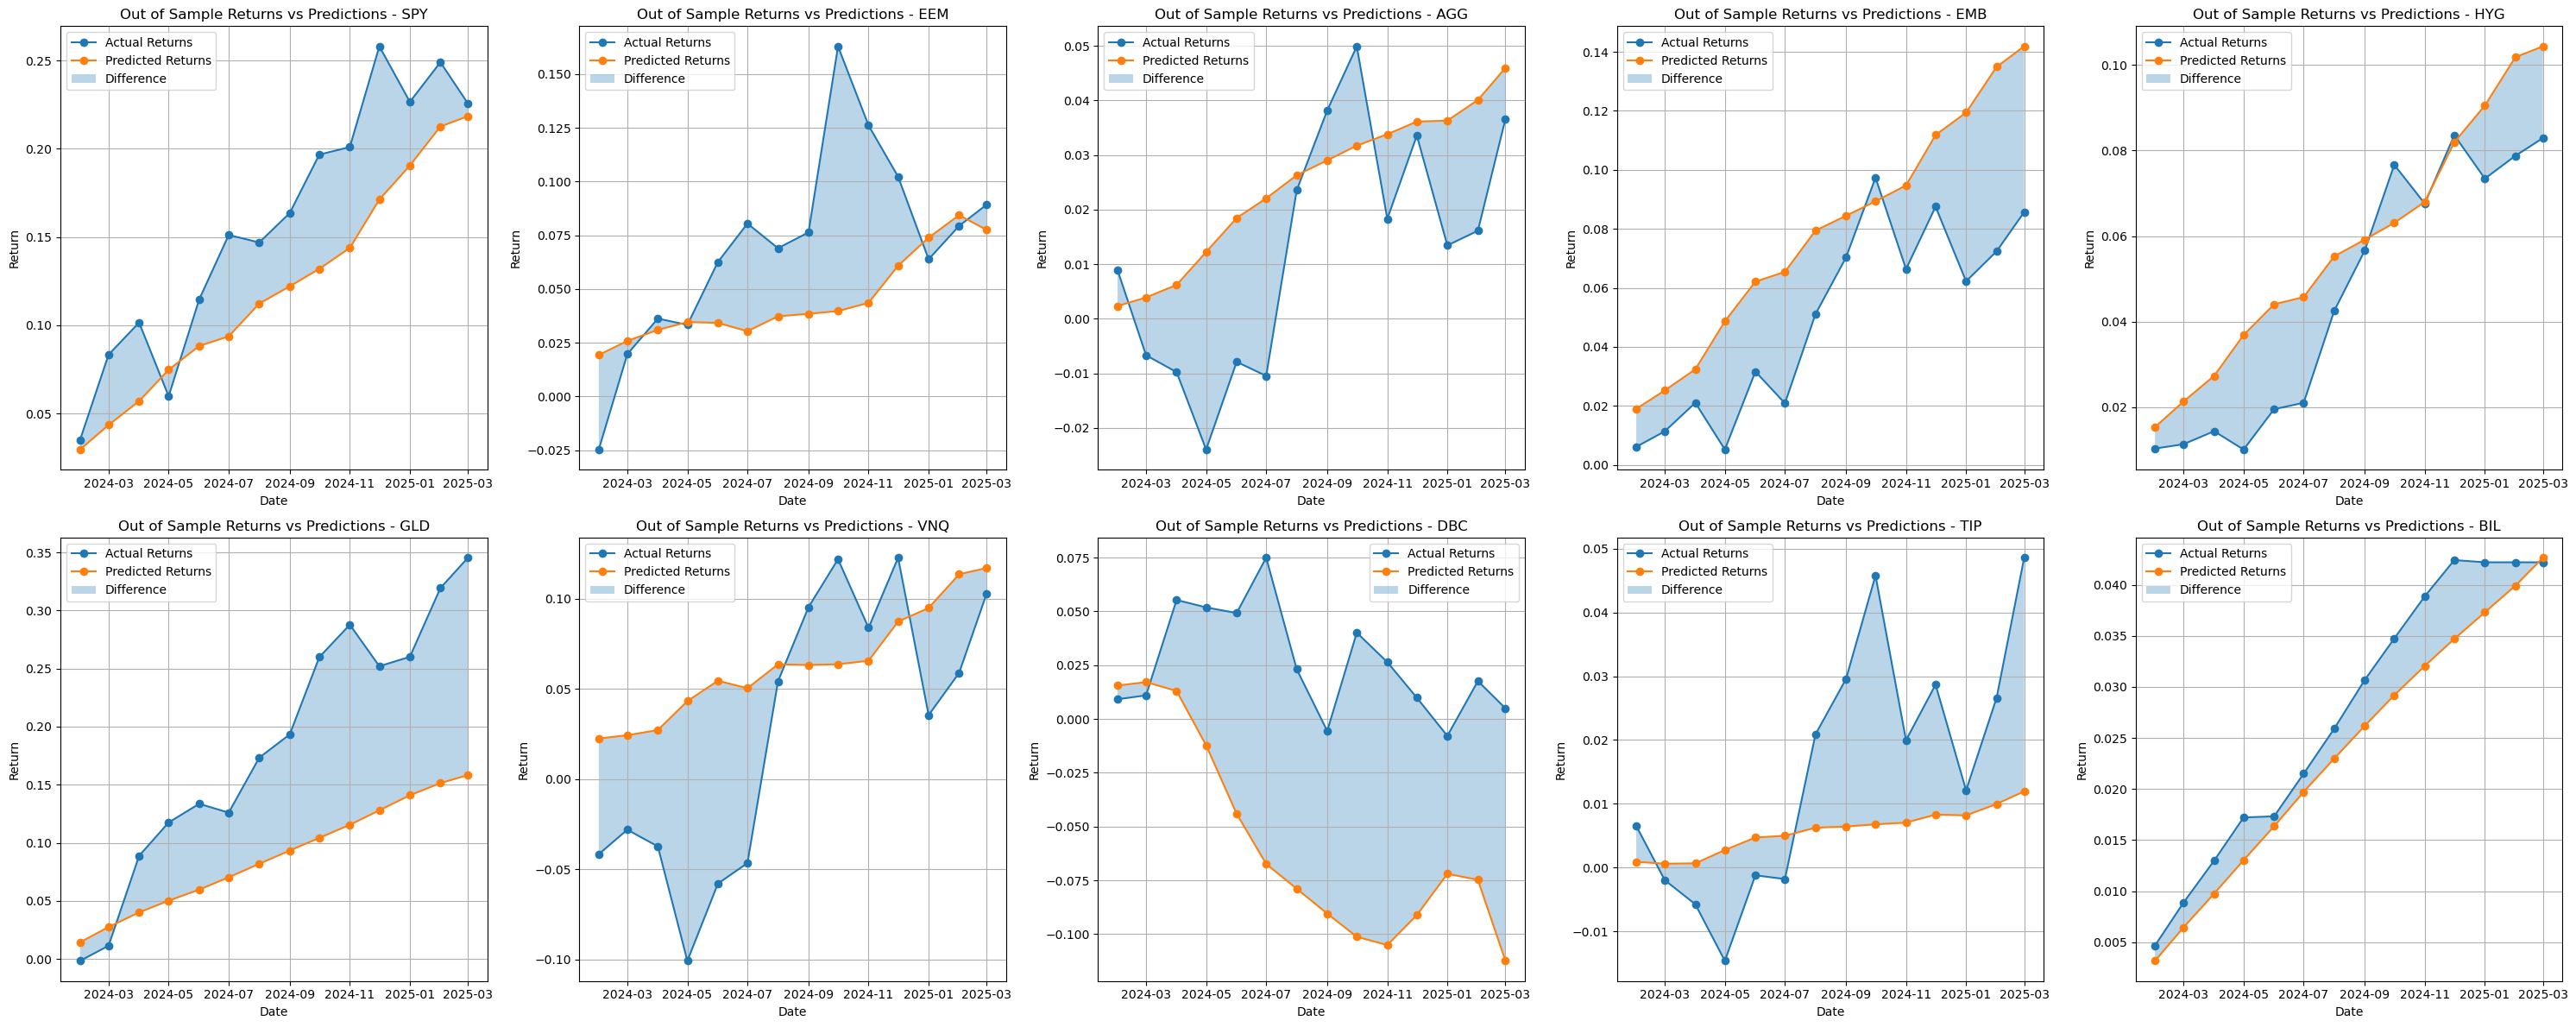

In [160]:
oos_pred = sm.add_constant(oos_macro_data) @ summary.loc[:'INDPRO']
oos_returns = oos_returns.loc[oos_pred.index]

fig, axes = plt.subplots(2, 5, figsize=(30, 12))
axes = axes.flatten()

for i, (ax, ticker) in enumerate(zip(axes, tickers)):
    ax.plot(oos_returns.index, oos_returns[ticker].cumsum(), label='Actual Returns', marker='o')
    ax.plot(oos_returns.index, oos_pred[ticker].cumsum(), label='Predicted Returns', marker='o')
    ax.fill_between(oos_returns.index,
                    oos_returns[ticker].cumsum(),
                    oos_pred[ticker].cumsum(),
                    alpha=0.3,
                    label='Difference')
    ax.set_title(f'Out of Sample Returns vs Predictions - {ticker}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Return')
    ax.legend()
    ax.grid(True)

plt.tight_layout()


## 7. Why did certain assets lead/lag?

Overall, the _direction_ of the forecasts were generally right. Further, forecasts for assets which had a high in-sample R-squared were close to real returns. There are several reasons why certain assets led/lagged over the macro forecasts:
- Stagflation: the stagflationary period over the last year wasn't sufficiently represented in the regression sample. This could lead to bad forecasts.
- Other exogenous factors: although the chosen macro factors explain a decent bit of return variation, there are far more factors that drive returns. This leads to omitted variable bias. The leads/lags we observe could just be a result of some exogenous variable we haven't included in our study.

## 8. Any trades?

I don't think that these results are suggestive of any trades. The limited data and omitted variable bias make the regression betas ill-formed. We can observe this in the residuals of the regression. The residuals seem to be correlated with the exogenous macro factors; this suggests there are other variables not included in the study which are driving returns. As such, I would not be confident in trading based on deviations from forecasts. It is much more likely that my model is misspecified than there is an actual mispricing.

## 10. PC Analysis

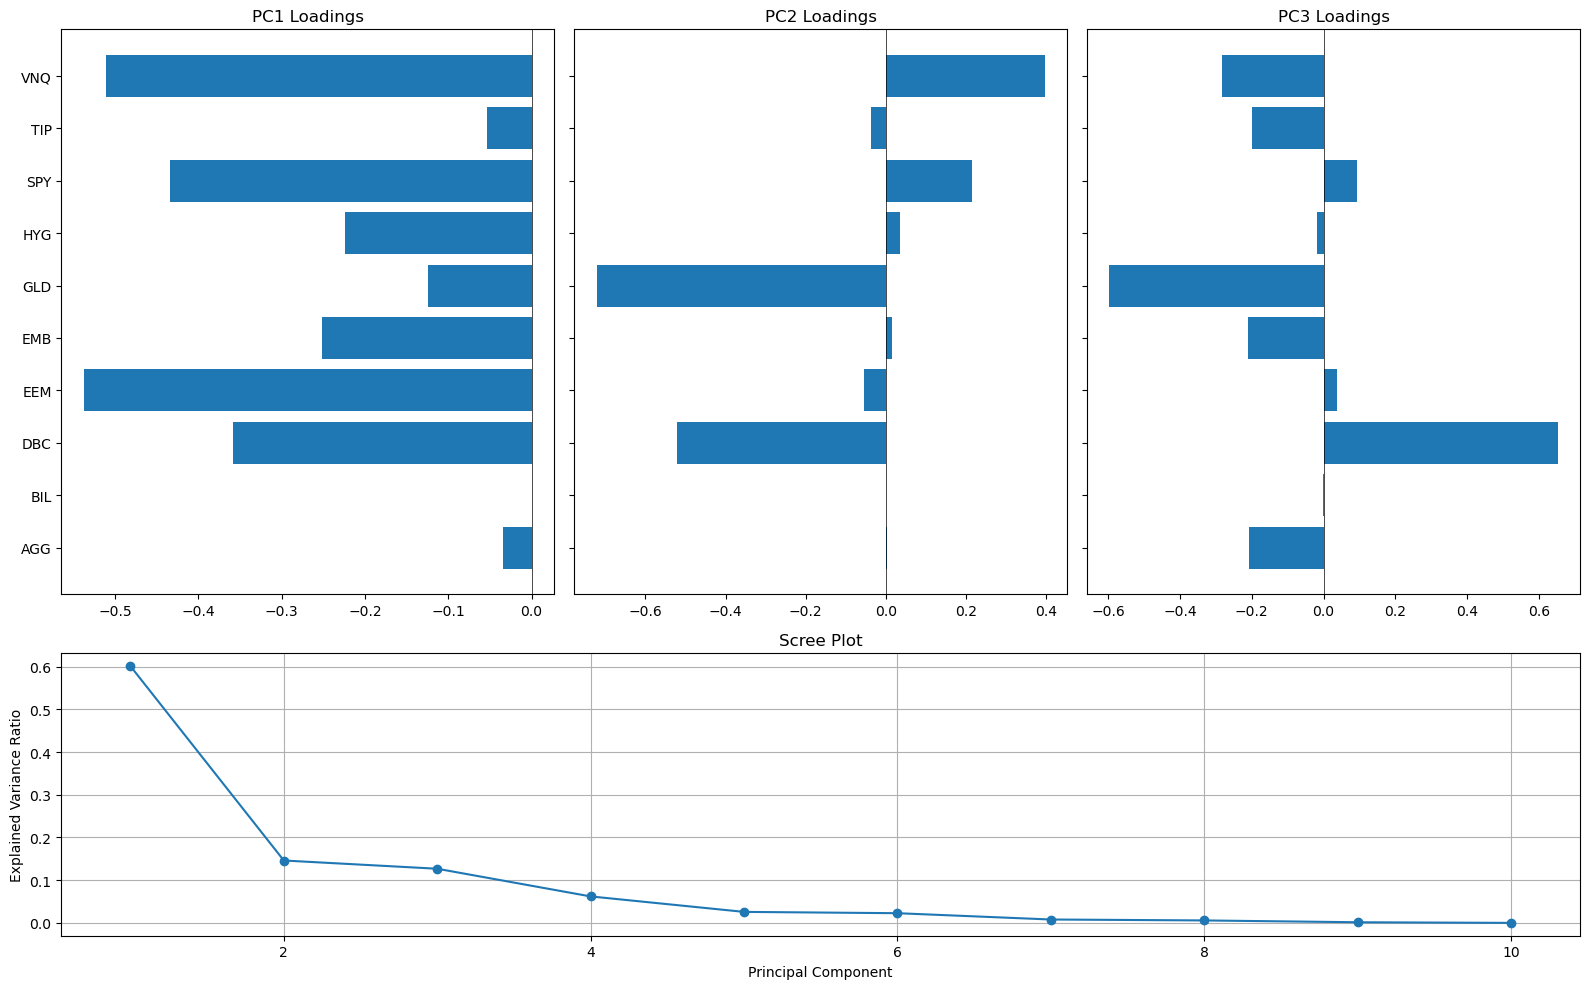

In [225]:
cov = (monthly_returns-monthly_returns.mean()).cov()
eigvals, eigvecs = np.linalg.eigh(cov)

eigvals_ordered = eigvals[::-1]
eigvecs_ordered = eigvecs[:, ::-1]

explained_var_ratio = eigvals_ordered / np.sum(eigvals_ordered)
asset_labels = z_score_returns.columns.tolist()
num_assets = len(asset_labels)

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, height_ratios=[2, 1])

for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    ax.barh(range(num_assets), eigvecs_ordered[:, i])
    ax.set_yticks(range(num_assets))
    if i == 0:
        ax.set_yticklabels(asset_labels)
    else:
        ax.set_yticklabels([]) 
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(f'PC{i+1} Loadings')

ax_scree = fig.add_subplot(gs[1, :])
ax_scree.plot(range(1, len(explained_var_ratio)+1), explained_var_ratio, marker='o')
ax_scree.set_xlabel("Principal Component")
ax_scree.set_ylabel("Explained Variance Ratio")
ax_scree.set_title("Scree Plot")
ax_scree.grid(True)

plt.tight_layout()
plt.show()


This PC plot tells us a few things:

- The first 3 principal components explain over $80\%$ of the variation in the data
- According to **PC1** (~$60\%$ of variation), there are strong and loadings in the same direction for **US Real Estate, TIPs, US Stocks, US High Yield Bonds, Gold, EM Bonds, EM Equity, Commodities, and US Aggregate Bonds**. This says that in certain macro regimes (at least in the period from 2010-2025), these assets all co-load on similar latent factors (global growth, inflation shocks, risk appetite).
- **PC2**, which explains roughly $15\%$ of the variation, captures a distinct and orthogonal source of variation. Here, assets like **Gold, TIPs, and US Aggregate Bonds** exhibit notable co-loadings, often associated with risk-off or flight-to-safety behaviors. This component likely captures investor responses to deflationary or recessionary conditions, where safer assets outperform.

## 12. Predictions Using PCs

In [226]:
X = (monthly_returns-monthly_returns.mean()) @ eigvecs_ordered[:, :3]
X = sm.add_constant(X)
y = monthly_returns

summary = pd.DataFrame()
for ticker in tickers:
    y = monthly_returns[ticker]
    reg = sm.OLS(y, X).fit()
    
    summary[ticker] = pd.concat([
        reg.params,
        pd.Series([reg.fvalue], index=['f_stat']),
        pd.Series([reg.rsquared], index=['r_squared']),
    ])

summary.index = summary.index.map({
    'const': 'Intercept',
    0: 'PC1',
    1: 'PC2',
    2: 'PC3',
    'f_stat': 'F-Statistic',
    'r_squared': 'R²'
})

summary.round(3)

,SPY,EEM,AGG,EMB,HYG,GLD,VNQ,DBC,TIP,BIL
Intercept,0.011,0.003,0.002,0.003,0.004,0.004,0.009,0.001,0.002,0.001
PC1,-0.434,-0.538,-0.034,-0.252,-0.224,-0.124,-0.511,-0.358,-0.054,0.001
PC2,0.215,-0.055,0.003,0.015,0.035,-0.721,0.396,-0.520,-0.036,-0.000
PC3,0.094,0.036,-0.208,-0.211,-0.017,-0.597,-0.284,0.652,-0.198,-0.002
F-Statistic,366.728,256.952,70.082,162.929,188.797,2397.237,443.162,1088.175,50.387,0.542
R²,0.870,0.825,0.562,0.749,0.775,0.978,0.890,0.952,0.480,0.010


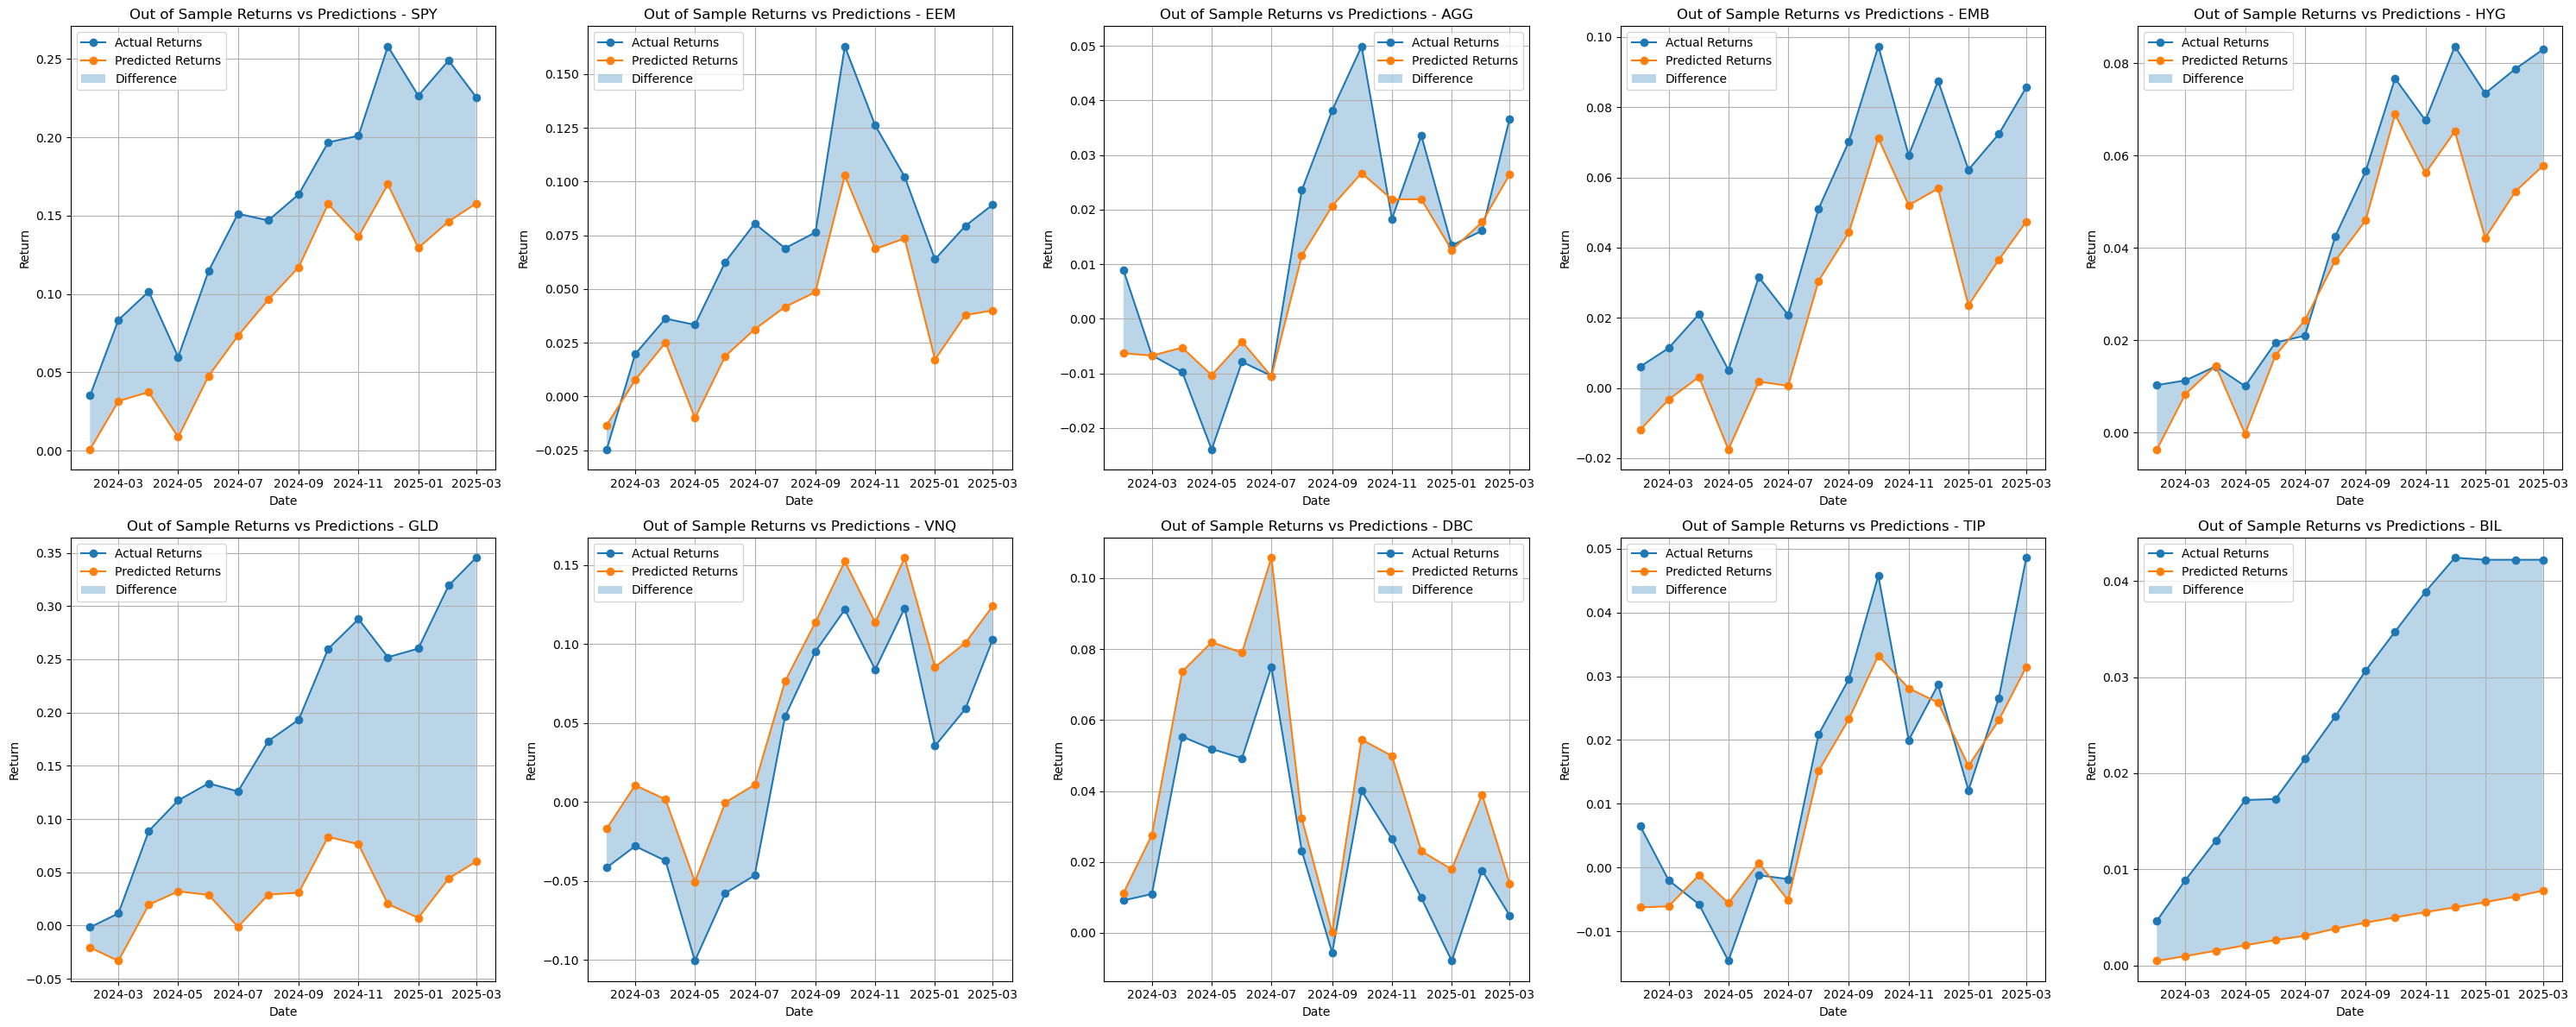

In [232]:
oos_factors = (oos_returns-oos_returns.mean()) @ eigvecs_ordered[:, :3]
oos_pred_np = (sm.add_constant(oos_factors)).to_numpy() @ (summary.loc[:'PC3']).to_numpy()
oos_pred = pd.DataFrame(oos_pred_np, columns=summary.columns.tolist(), index=oos_factors.index)
oos_returns = oos_returns.loc[oos_pred.index]

fig, axes = plt.subplots(2, 5, figsize=(30, 12))
axes = axes.flatten()

for i, (ax, ticker) in enumerate(zip(axes, tickers)):
    ax.plot(oos_returns.index, oos_returns[ticker].cumsum(), label='Actual Returns', marker='o')
    ax.plot(oos_returns.index, oos_pred[ticker].cumsum(), label='Predicted Returns', marker='o')
    ax.fill_between(oos_returns.index,
                    oos_returns[ticker].cumsum(),
                    oos_pred[ticker].cumsum(),
                    alpha=0.3,
                    label='Difference')
    ax.set_title(f'Out of Sample Returns vs Predictions - {ticker}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Return')
    ax.legend()
    ax.grid(True)

plt.tight_layout()


Most of the assets had very high $R^2$ values as a result of the PCA factor decomposition. In this context, we are using the PCs as "latent macro factors" to see if there's more explainability in the variance of the data itself. Assets like **SPY, EEM, AGG, and HYG** lagged predictions. **VNQ** very closely hugged predictions; it also had the highest loading in PC1, which makes sense.  

Economic inspection signifies the possibilities that:
- PC1 represents a global growth/inflation regime
- PC2 represents a global risk-off, flight to safety regime
- PC3 seems to mostly be residual noise

## 13. Lead/Lag Relationships

Certain assets may head led or lagged broader cross-asset performance because of many factors in the past year, including:
- **Election effects:** Trump's inauguration and statements on air have had huge market impacts recently. The PCs could not have priced this in because something like this hasn't happened before.
- **A transitory period from PC1 to PC2:** We are just coming off of a huge correction from a highly inflationary couple years. In terms of the PCs, we would be expecting a transition from a risk-on worldview into safer assets. So it's possible that this could have contributed to any lags.
- **Generally,** each asset here has its own thematic rate of rate sensitivity, credit risk, and idiosyncratic risk drivers. Similarly to predictions with the macro factors earlier, we just may not be accounting for other exogenous factors that contribute to price movement.

## 14. Any trades?

These factors seem to have more prediction power to them than the macro factors earlier, so a trade could be formulated but it'd have to be closely risk managed. First off, we could employ techniques like bagging, to increase confidence in the stability of our PC loadings. Then, using the residuals from predictions in test data, we could formulate a trade where we allocate more capital to assets with smaller residual values, but make sure to diversify (and ideally add more assets into the universe). A good thing here is that **for most of the assets, the predictions were lower than the actual returns**. And for the ones that the predictions were higher, they were only marginally higher. 